In [1]:
import data_loader
import plotting
import dispatch
from pathlib import Path
import pandas as pd
import numpy as np
import scenarios
from functools import partial

# Plant and market parameters
CCGT_POWER = 400          # MW
HEAT_RATE = 1.95          # MWh of gas burned per MWh of electricity
SWITCH_ON_COST = 15000    # EUR per start-up
MIN_ON_TIME = 4           # hours
MIN_OFF_TIME = 4          # hours
EMISSION_FACTOR = 0.37    # tons of CO2 per MWh of electricity
CO2_PRICE = 70            # EUR/ton

# CCGT valuation & dispatch optimization

Valuation of a combined-cycle gas turbine (CCGT) plant modelled as a strip of
spark-spread options, using 2023 Italian day-ahead electricity prices (PUN) and
Dutch TTF gas prices.

This notebook loads and inspects the price data, computes the spark spread,
values the plant under three dispatch strategies, and closes with a Monte Carlo
over resampled price years. The valuation and dispatch logic lives in the
project modules (`data_loader`, `dispatch`, `plotting`, `scenarios`).

## 1. Load price data

Hourly PUN and daily TTF prices are loaded and aligned by
`data_loader.load_pun_ttf_prices`, which merges the daily gas price onto the
hourly grid (forward-filled over weekends and holidays) and returns one row per
hour in chronological order. With `diagnostic=True` it also checks the load for
missing values and the expected per-day hour counts.

In [2]:
year = 2023   # available years: 2022, 2023, 2024, 2025

pun_ttf_prices = data_loader.load_pun_ttf_prices(diagnostic=True, year=year)

display(pun_ttf_prices.head())
display(pun_ttf_prices.tail())

diagnostic OK: 8760 hours, 365 days (363 x 24h, one 23h, one 25h), no missing values


,time,pun_price,ttf_price
0,2023-01-01 00:00:00,195.90,76.315
1,2023-01-01 01:00:00,191.09,76.315
2,2023-01-01 02:00:00,187.95,76.315
3,2023-01-01 03:00:00,187.82,76.315
4,2023-01-01 04:00:00,187.74,76.315


,time,pun_price,ttf_price
8755,2023-12-31 19:00:00,136.07000,32.35
8756,2023-12-31 20:00:00,130.00000,32.35
8757,2023-12-31 21:00:00,117.23116,32.35
8758,2023-12-31 22:00:00,108.96000,32.35
8759,2023-12-31 23:00:00,106.12000,32.35


## 2. Spark spread

The clean spark spread is the hourly operating margin: the power price net of
fuel and carbon cost. Positive hours are the ones worth running.

In [3]:
pun_ttf_prices["spark_spread"]=dispatch.compute_spark_spread(
    pun_price=pun_ttf_prices["pun_price"], 
    ttf_price=pun_ttf_prices["ttf_price"], 
    heat_rate=HEAT_RATE, 
    emission_factor=EMISSION_FACTOR, 
    co2_price=CO2_PRICE,
)

pun_ttf_prices.head()

,time,pun_price,ttf_price,spark_spread
0,2023-01-01 00:00:00,195.90,76.315,21.18575
1,2023-01-01 01:00:00,191.09,76.315,16.37575
2,2023-01-01 02:00:00,187.95,76.315,13.23575
3,2023-01-01 03:00:00,187.82,76.315,13.10575
4,2023-01-01 04:00:00,187.74,76.315,13.02575


(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Spark spread — hourly, sample week (2023)'}, ylabel='€/MWh'>)

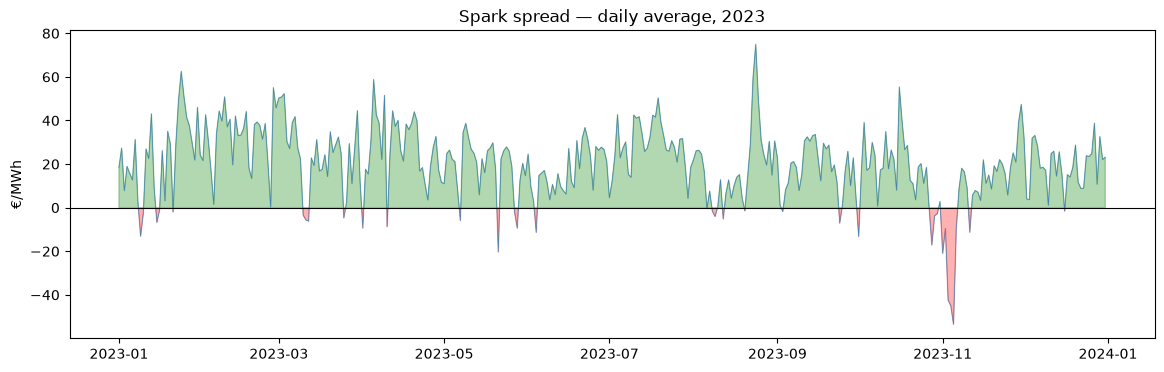

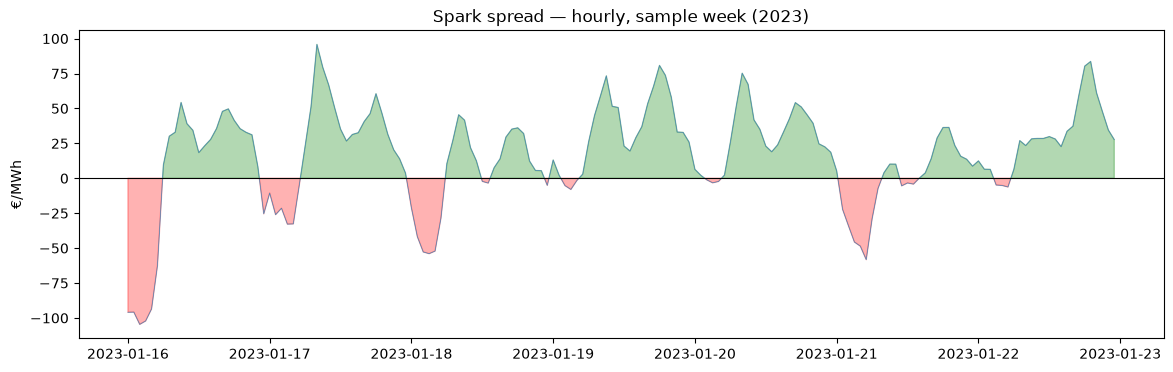

In [4]:
# daily average
daily = (
    pun_ttf_prices.set_index("time")["spark_spread"]
    .resample("D")
    .mean()
)

plotting.plot_series_vs_threshold(
    daily.index, daily.values,
    title=f"Spark spread — daily average, {year}", ylabel="€/MWh",
)

# sample week
start_week = f"{year}-01-16"
end_week = f"{year}-01-23"
week = pun_ttf_prices[(pun_ttf_prices["time"] >= start_week) &
                      (pun_ttf_prices["time"] < end_week)]
plotting.plot_series_vs_threshold(
    week["time"], week["spark_spread"],
    title=f"Spark spread — hourly, sample week ({year})", ylabel="€/MWh",
)

## 3. Dispatch strategies

The plant is valued under three strategies of increasing realism: the naive
must-run baseline, the unconstrained ideal (the option ceiling), and the
constrained optimum from the dynamic-programming solver.

### Always on — must-run baseline

In [5]:
total_revs_naive = pun_ttf_prices["spark_spread"].sum() * CCGT_POWER
formatted_revs_naive = f"{total_revs_naive:,.0f}".replace(",", " ")

print(f"Always on — yearly gross margin: {formatted_revs_naive} EUR")

Always on — yearly gross margin: 71 917 741 EUR


### Ideal — unconstrained (switching free and always possible)

In [6]:
total_revs_ideal = (
    pun_ttf_prices[pun_ttf_prices["spark_spread"] > 0]["spark_spread"]
    .sum() * CCGT_POWER
)
formatted_revs_ideal = f"{total_revs_ideal:,.0f}".replace(",", " ")

diff_ideal_naive = total_revs_ideal - total_revs_naive
formatted_diff_ideal_naive = f"{diff_ideal_naive:,.0f}".replace(",", " ")

print(
    f"Ideal, unconstrained — yearly gross margin: {formatted_revs_ideal} EUR\n"
    f"({formatted_diff_ideal_naive} EUR more than always on)"
)

Ideal, unconstrained — yearly gross margin: 83 898 736 EUR
(11 980 994 EUR more than always on)


### Optimal — constrained (dynamic programming)

In [7]:
constraints={
    "min_on_time":MIN_ON_TIME,
    "min_off_time":MIN_OFF_TIME,
    "switch_on_cost": SWITCH_ON_COST,
    "ccgt_power": CCGT_POWER
}

is_on_dispatch, optimal_real_revs = dispatch.compute_optimal_dispatch(
    hourly_prices=pun_ttf_prices, 
    constraints=constraints
)

pun_ttf_prices["optimal_dispatch"]=is_on_dispatch


n_startups=dispatch.count_startups(is_on_dispatch)

formatted_startup_costs= f"{n_startups*SWITCH_ON_COST:,.0f}".replace(",", " ")


formatted_revs_real = f"{optimal_real_revs:,.0f}".replace(",", " ")

run_at_loss=(
    pun_ttf_prices[(
        (pun_ttf_prices["spark_spread"]<0) & 
        (pun_ttf_prices["optimal_dispatch"]==True))]["spark_spread"]
    .sum()*CCGT_POWER
)
formatted_run_at_loss_costs= f"{abs(run_at_loss):,.0f}".replace(",", " ")


off_when_profitable=(
    pun_ttf_prices[
        ((pun_ttf_prices["spark_spread"]>0) & 
        (pun_ttf_prices["optimal_dispatch"]==False))]["spark_spread"]
    .sum()*CCGT_POWER
)
formatted_off_when_profitable_costs= f"{abs(off_when_profitable):,.0f}".replace(",", " ")

optimal_minus_naive=optimal_real_revs-total_revs_naive
formatted_optimal_minus_naive= f"{optimal_minus_naive:,.0f}".replace(",", " ")



### Saving outputs

In [8]:
Path("output").mkdir(parents=True, exist_ok=True)

dispatch_df = pd.DataFrame({
    "hour": range(len(is_on_dispatch)),
    "status": ["ON" if x else "OFF" for x in is_on_dispatch],
})
dispatch_df.to_csv("output/optimal_dispatch.csv", index=False)

summary_text = (
    f"Optimal constrained dispatch for {year}. Hourly on/off profile saved to "
    f"optimal_dispatch.csv.\n\n"
    f"Ideal, unconstrained gross margin : {formatted_revs_ideal} EUR\n"
    f"Optimal, constrained gross margin : {formatted_revs_real} EUR\n\n"
    f"The gap between the two is the cost of the operational constraints:\n"
    f"- start-up costs ({n_startups} start-ups): {formatted_startup_costs} EUR\n"
    f"- run at loss (ON when unprofitable): {formatted_run_at_loss_costs} EUR\n"
    f"- profit foregone (OFF when profitable): {formatted_off_when_profitable_costs} EUR\n\n"
    f"For reference, running always on would earn {formatted_revs_naive} EUR, "
    f"i.e. {formatted_optimal_minus_naive} EUR less than the constrained optimum."
)

print(summary_text)

with open("output/analysis_summary.txt", "w") as f:
    f.write(summary_text)

Optimal constrained dispatch for 2023. Hourly on/off profile saved to optimal_dispatch.csv.

Ideal, unconstrained gross margin : 83 898 736 EUR
Optimal, constrained gross margin : 80 991 005 EUR

The gap between the two is the cost of the operational constraints:
- start-up costs (134 start-ups): 2 010 000 EUR
- run at loss (ON when unprofitable): 805 928 EUR
- profit foregone (OFF when profitable): 91 803 EUR

For reference, running always on would earn 71 917 741 EUR, i.e. 9 073 263 EUR less than the constrained optimum.


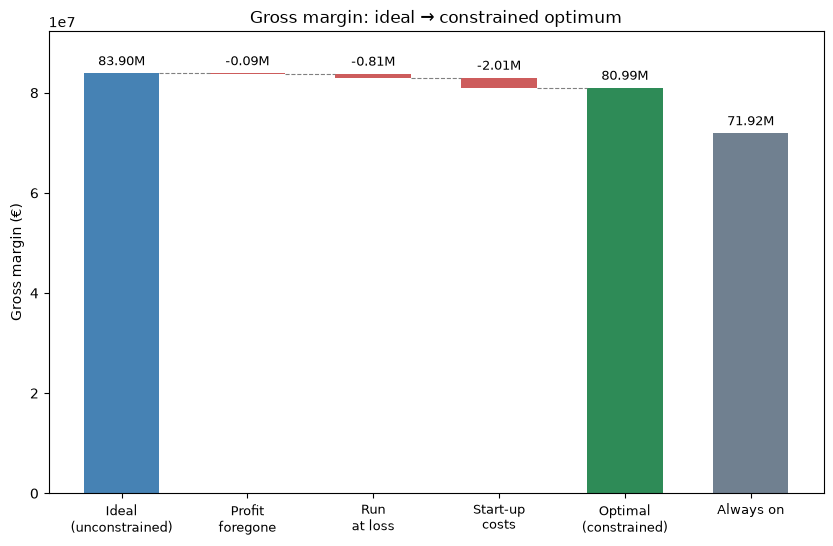

In [9]:
fig, ax = plotting.plot_value_waterfall(
    spark_spread=pun_ttf_prices["spark_spread"],
    is_on=is_on_dispatch,
    capacity=CCGT_POWER,
    n_startups=n_startups,
    switch_on_cost=SWITCH_ON_COST,
    value_optimal_dp=optimal_real_revs,
)
fig.savefig("output/value_waterfall.png", dpi=150, bbox_inches="tight")

## 4. Monte Carlo valuation

The 2023 result is a single historical path. To get the *distribution* of
annual value, synthetic years are built by **monthly block bootstrap**: each
calendar month is drawn from a random year in the pool
(`scenarios.generate_year_bootstrap_monthly`), and the DP is solved on each.

Each path is solved with **perfect foresight**, so the distribution is an upper
bound on realisable value, not an operating strategy. 2022 is left out of the
pool as a structural-break (energy-crisis) outlier, and Feb 29 is dropped so
every sampled year has the same length.

diagnostic OK: 8760 hours, 365 days (363 x 24h, one 23h, one 25h), no missing values
diagnostic OK: 8784 hours, 366 days (364 x 24h, one 23h, one 25h), no missing values
diagnostic OK: 8760 hours, 365 days (363 x 24h, one 23h, one 25h), no missing values
Monte Carlo — annual gross margin (1000 scenarios, perfect-foresight upper bound)
  mean:          72 965 239 EUR
  median:        72 862 041 EUR
  std dev:       5 628 487 EUR
  5th-95th pct:  63 911 883 - 82 282 084 EUR
  min / max:     56 197 234 / 90 548 361 EUR

Monte Carlo — start-ups per year
  mean:          145.5
  median:        146
  std dev:       19.6
  5th-95th pct:  113 - 177
  min / max:     90 / 208


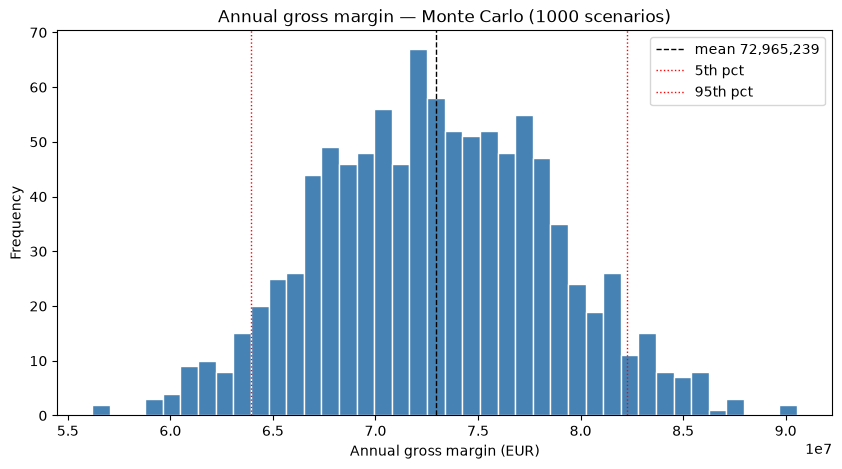

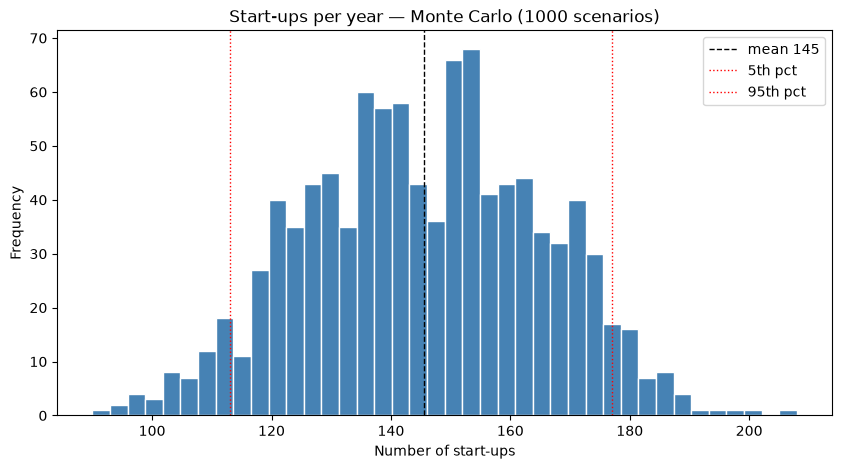

In [10]:
import random

# resampling pool: 2023–2025 (2022 excluded as a crisis outlier)
pool_years = (2023, 2024, 2025)

df_spark_spread = pd.DataFrame()
for y in pool_years:
    df = data_loader.load_pun_ttf_prices(diagnostic=True, year=y)
    df["spark_spread"] = dispatch.compute_spark_spread(
        pun_price=df["pun_price"],
        ttf_price=df["ttf_price"],
        heat_rate=HEAT_RATE,
        emission_factor=EMISSION_FACTOR,
        co2_price=CO2_PRICE,
    )
    df_spark_spread = pd.concat([df_spark_spread, df], ignore_index=True)

# drop Feb 29 so every sampled year has the same length
df_spark_spread = df_spark_spread[
    df_spark_spread["time"].dt.date != pd.Timestamp("2024-02-29").date()
]

random.seed(42)  # reproducible scenarios
generate_year = partial(scenarios.generate_year_bootstrap_monthly, df_spark_spread)

profits_montecarlo, n_startups_montecarlo = dispatch.monte_carlo_profits(
    year_generator=generate_year,
    constraints=constraints,
    n_scenarios=1000,
)

profits = np.array(profits_montecarlo)
startups = np.array(n_startups_montecarlo)


def fmt(x):
    return f"{x:,.0f}".replace(",", " ")


print("Monte Carlo — annual gross margin (1000 scenarios, perfect-foresight upper bound)")
print(f"  mean:          {fmt(profits.mean())} EUR")
print(f"  median:        {fmt(np.median(profits))} EUR")
print(f"  std dev:       {fmt(profits.std())} EUR")
print(f"  5th-95th pct:  {fmt(np.percentile(profits, 5))} - {fmt(np.percentile(profits, 95))} EUR")
print(f"  min / max:     {fmt(profits.min())} / {fmt(profits.max())} EUR")

print()
print("Monte Carlo — start-ups per year")
print(f"  mean:          {startups.mean():.1f}")
print(f"  median:        {np.median(startups):.0f}")
print(f"  std dev:       {startups.std():.1f}")
print(f"  5th-95th pct:  {np.percentile(startups, 5):.0f} - {np.percentile(startups, 95):.0f}")
print(f"  min / max:     {startups.min()} / {startups.max()}")

Path("output/plots").mkdir(parents=True, exist_ok=True)

fig_profit, _ = plotting.plot_distribution(
    profits_montecarlo,
    title="Annual gross margin — Monte Carlo (1000 scenarios)",
    xlabel="Annual gross margin (EUR)",
)
fig_profit.savefig("output/plots/montecarlo_distribution.png", dpi=150, bbox_inches="tight")

fig_startups, _ = plotting.plot_distribution(
    n_startups_montecarlo,
    title="Start-ups per year — Monte Carlo (1000 scenarios)",
    xlabel="Number of start-ups",
)
fig_startups.savefig("output/plots/montecarlo_startups.png", dpi=150, bbox_inches="tight")